# Heart Disease Prediction - Advanced Data Exploration, Statistical Analysis & Feature Engineering
### Week 3: AnalystLab Africa - Data Science Internship Programme
**Client scenario:** Junior Data Scientist at AnalystLab Africa Consulting

**Dataset:** Heart Failure Prediction Dataset (Kaggle), continuing from the Week 2 cleaned dataset

**Objective:** Uncover hidden patterns, statistically validate business assumptions, engineer meaningful features, and prepare a final machine-learning-ready dataset ahead of Week 4 model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, RobustScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

df = pd.read_csv("heart_cleaned.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBloodSugarHigh,RestingECG,MaxHR,ExerciseAngina,ST_Depression,ST_Slope,HeartDisease,HR_Reserve
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,8
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,15
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,85
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,64
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,44


## Part 1 - Advanced Data Quality Assessment
Reviewing the Week 2 cleaned dataset before deeper statistical work.

In [2]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Shape: 918 rows x 13 columns
Missing values: 0
Duplicate rows: 0


In [3]:
df.dtypes

Age                        int64
Sex                       object
ChestPainType             object
RestingBP                float64
Cholesterol              float64
FastingBloodSugarHigh      int64
RestingECG                object
MaxHR                      int64
ExerciseAngina            object
ST_Depression            float64
ST_Slope                  object
HeartDisease               int64
HR_Reserve                 int64
dtype: object

**Data consistency:** all categorical columns (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) contain a fixed, valid set of category labels with no typos or inconsistent casing (verified below). All numeric columns fall within physiologically plausible ranges following the Week 2 cleaning (invalid zero-values in `RestingBP`/`Cholesterol` were imputed, and extreme values capped).

In [4]:
for col in ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']:
    print(f"{col}: {sorted(df[col].unique())}")

Sex: ['F', 'M']
ChestPainType: ['ASY', 'ATA', 'NAP', 'TA']
RestingECG: ['LVH', 'Normal', 'ST']
ExerciseAngina: ['N', 'Y']
ST_Slope: ['Down', 'Flat', 'Up']


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
RestingBP,918.0,132.168845,16.936369,90.0,120.0,130.0,140.0,170.0
Cholesterol,918.0,241.227124,45.069895,134.5,214.0,237.0,267.0,346.5
FastingBloodSugarHigh,918.0,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ST_Depression,918.0,0.887364,1.066570,-2.6,0.0,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.0,1.0,1.0,1.0
HR_Reserve,918.0,29.679739,23.530853,-29.0,11.0,29.0,46.0,109.0


In [6]:
# Outlier re-check (IQR method) on the Week 2 cleaned data
cont_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression']
outlier_summary = {}
for col in cont_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_out
pd.Series(outlier_summary, name='Outliers remaining')

Age               0
RestingBP         0
Cholesterol       0
MaxHR             2
ST_Depression    16
Name: Outliers remaining, dtype: int64

In [7]:
# Class balance check
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True).round(3) * 100)

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64


**Summary of data quality after Week 2 cleaning:**
- No missing values, no duplicate records.
- All categorical values are clean and consistent.
- `RestingBP` and `Cholesterol` outlier counts are sharply reduced versus the raw data (Week 2 capped extreme values at the IQR bounds).
- The target class remains reasonably balanced (55.3% / 44.7%), so no resampling is required before modelling.

The dataset is confirmed in good shape to proceed to deeper exploratory and statistical analysis.

## Part 2 - Advanced Exploratory Data Analysis

### 2.1 Numerical Analysis

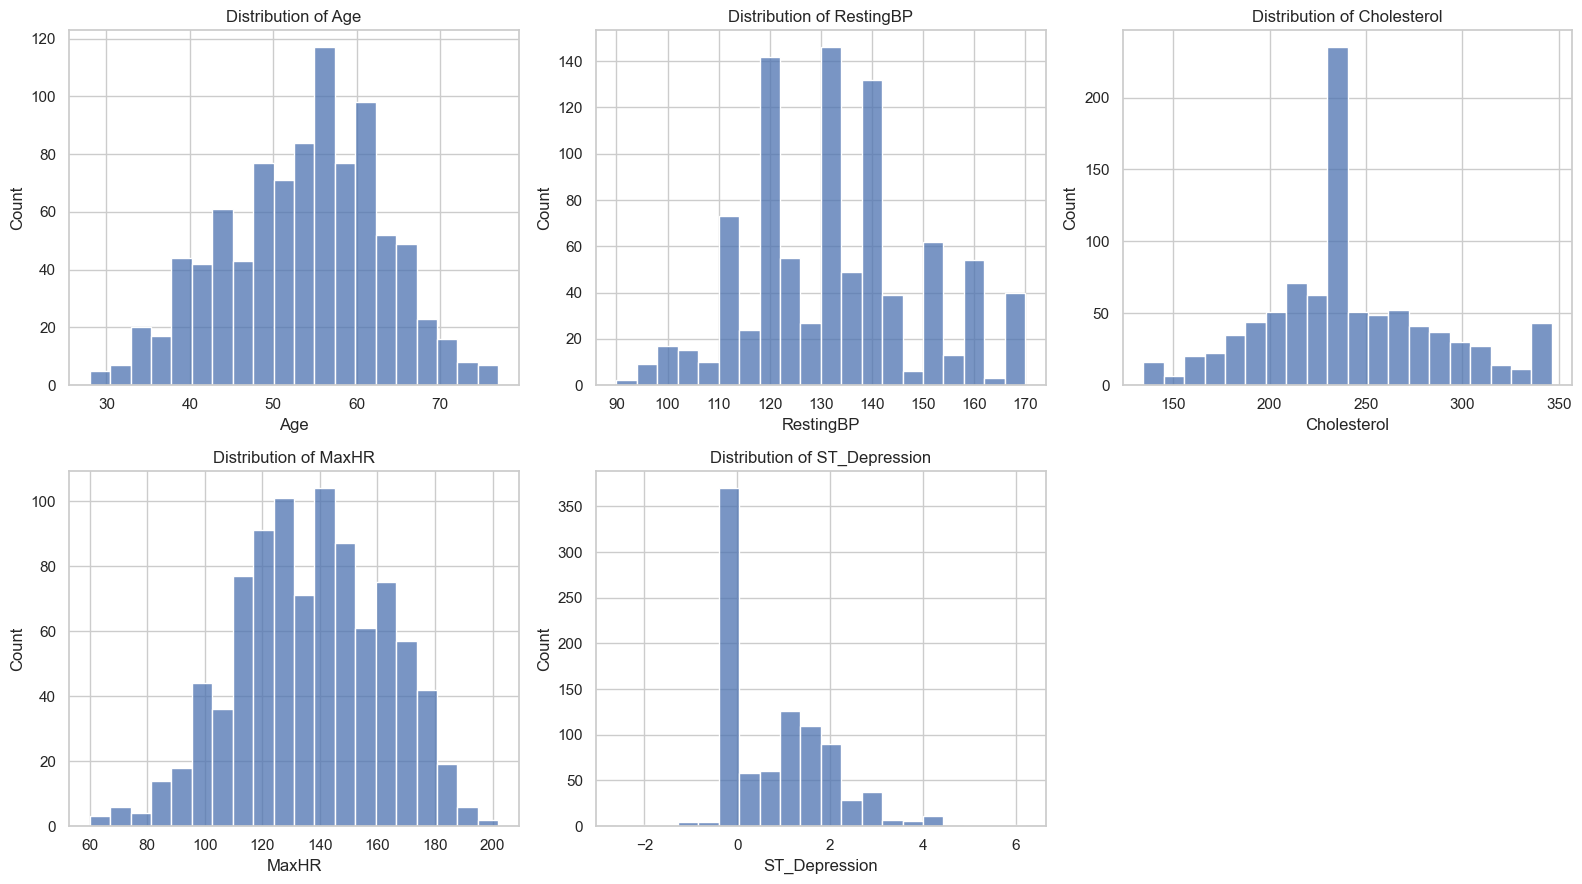

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cont_cols):
    sns.histplot(df[col], bins=20, kde=False, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

**Visualisations 1-5 (Histograms):** `Age` is roughly bell-shaped centred in the 50s. `RestingBP` and `Cholesterol` are both right-skewed with a concentration around typical clinical values post-cleaning. `MaxHR` is left-skewed, and `ST_Depression` is heavily right-skewed with a spike at 0 (no ST depression)  consistent with a clinical measurement that is zero for a majority of healthier patients.

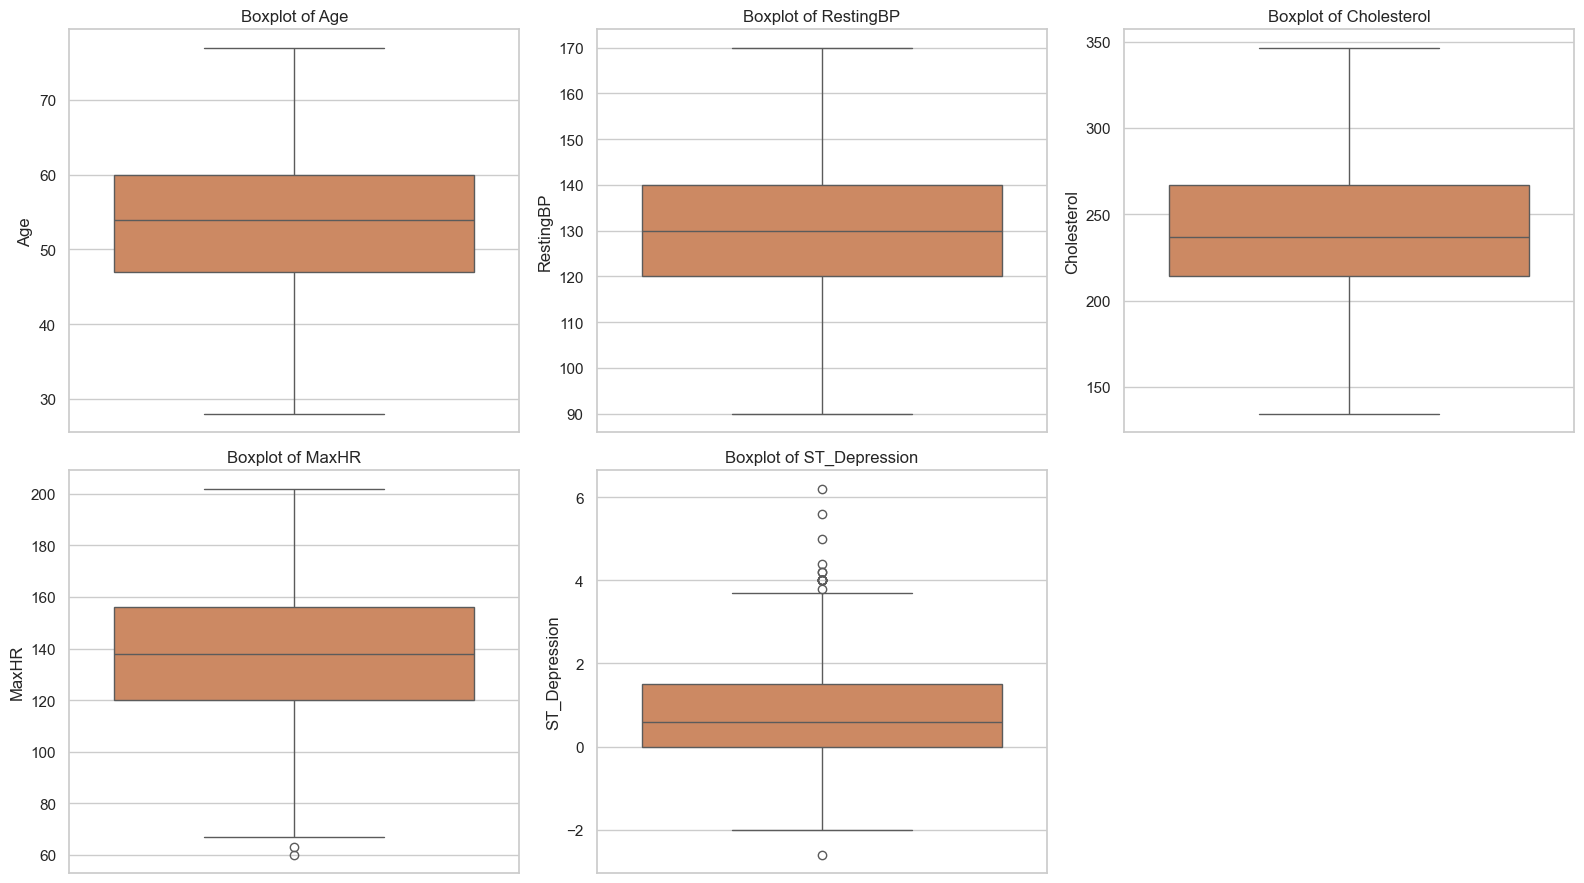

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cont_cols):
    sns.boxplot(y=df[col], ax=ax, color='#DD8452')
    ax.set_title(f'Boxplot of {col}')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

**Visualisations 6-10 (Boxplots):** confirm the histogram observations `Cholesterol` and `RestingBP` retain a handful of upper outliers even after Week 2 capping (natural clinical variation), while `ST_Depression` shows a long upper tail, reflecting genuinely severe cases rather than data errors.

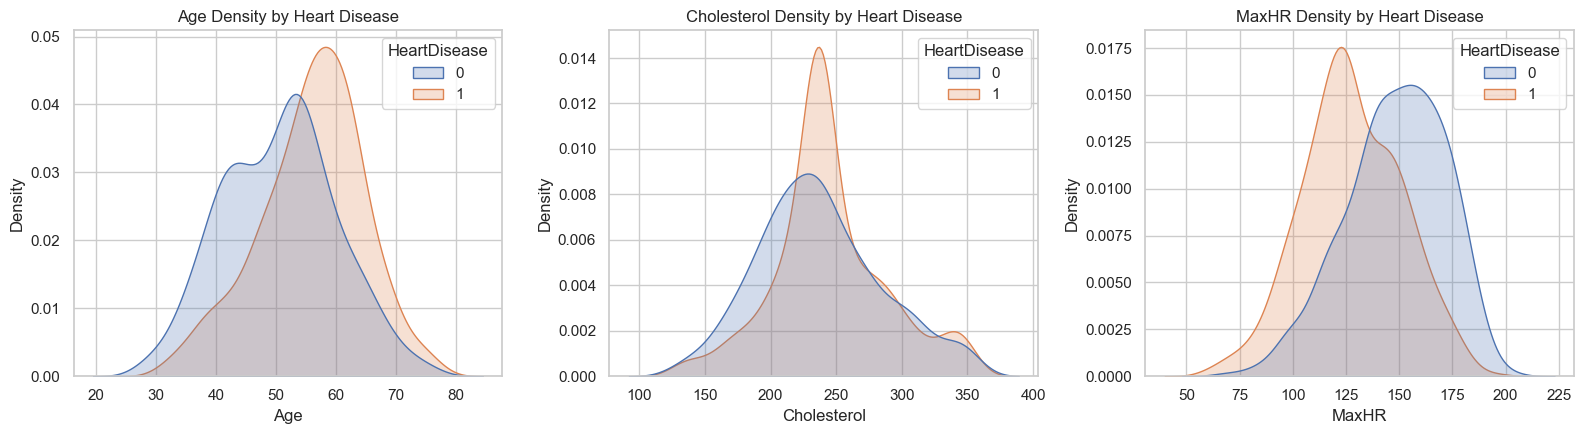

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['Age', 'Cholesterol', 'MaxHR']):
    sns.kdeplot(data=df, x=col, hue='HeartDisease', fill=True, common_norm=False, ax=ax, palette=['#4C72B0', '#DD8452'])
    ax.set_title(f'{col} Density by Heart Disease')
plt.tight_layout()
plt.show()

**Visualisations 11-13 (Density plots):** the density curves separate most clearly for `MaxHR` (patients with heart disease cluster at lower max heart rates) and `Age` (heart disease patients skew older), while `Cholesterol` densities overlap substantially, suggesting it is a weaker standalone discriminator.

### 2.2 Categorical Analysis

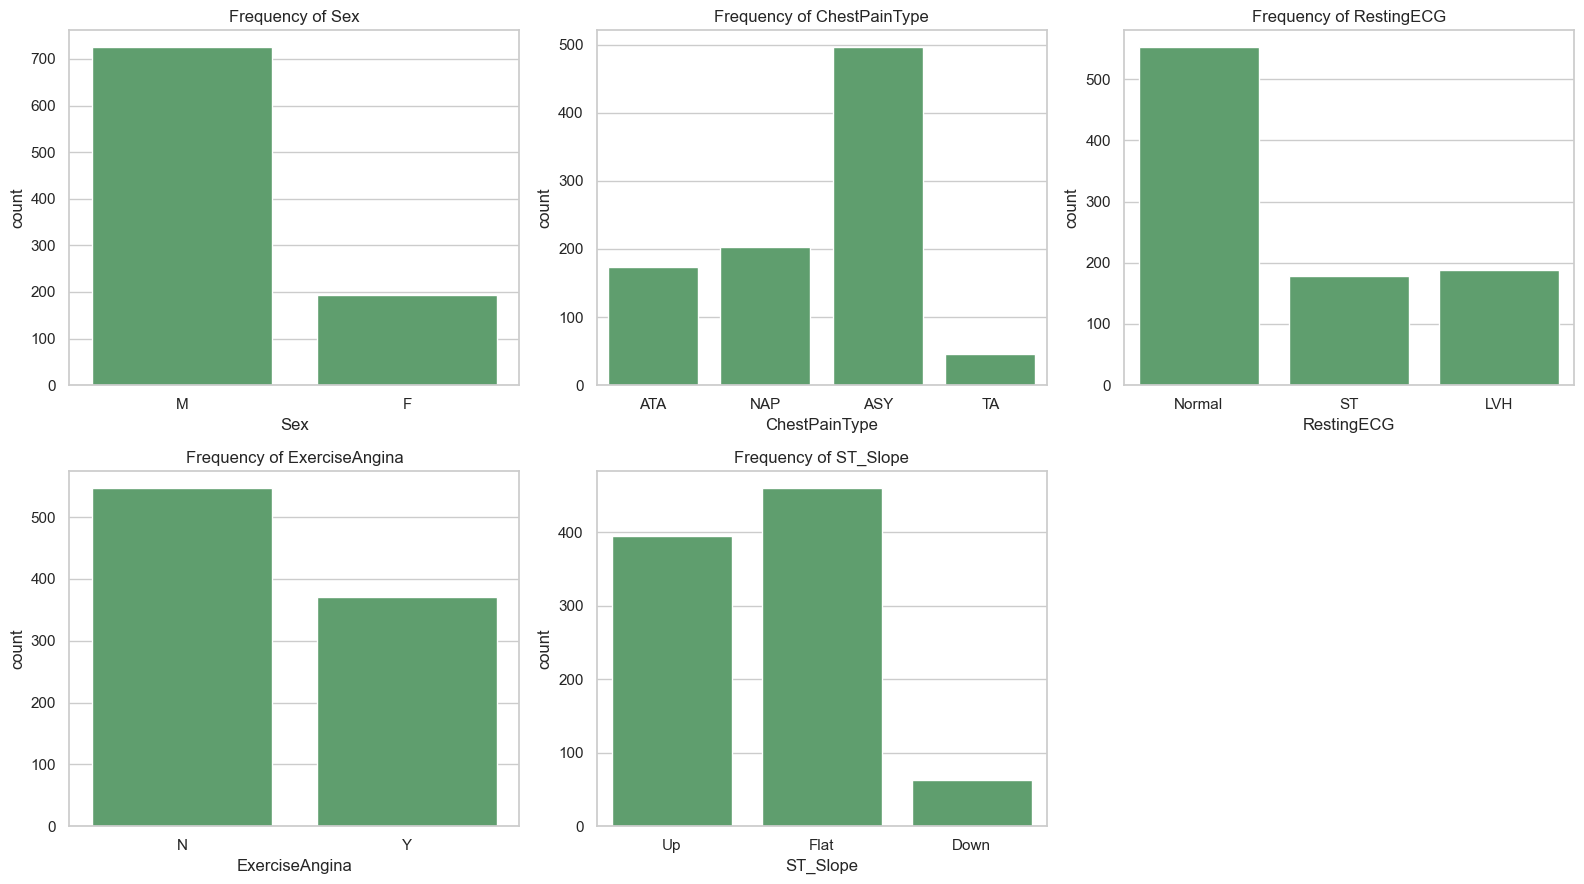

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for ax, col in zip(axes.flat, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, color='#55A868')
    ax.set_title(f'Frequency of {col}')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

**Visualisations 14-18 (Frequency distributions):** the dataset skews male (~72%), is dominated by asymptomatic (ASY) and normal-ECG patients, and most patients report no exercise-induced angina. `ST_Slope` is fairly evenly split between 'Up' and 'Flat', with 'Down' rare.

In [12]:
ct_percent = pd.crosstab(df['ChestPainType'], df['HeartDisease'], normalize='index') * 100
ct_percent.columns = ['No Heart Disease (%)', 'Heart Disease (%)']
ct_percent.round(1)

,No Heart Disease (%),Heart Disease (%)
ChestPainType,,
ASY,21.0,79.0
ATA,86.1,13.9
NAP,64.5,35.5
TA,56.5,43.5


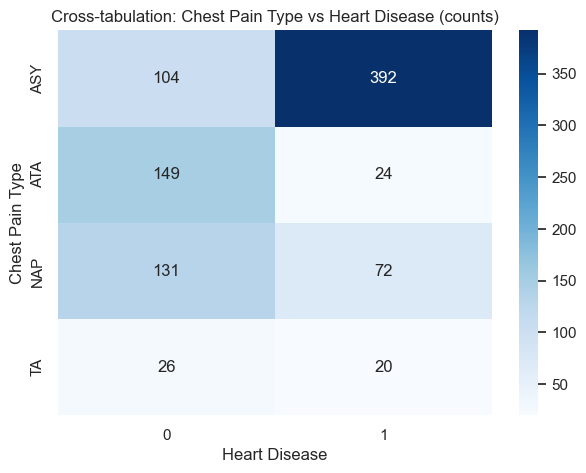

In [13]:
plt.figure(figsize=(7, 5))
ct_counts = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
sns.heatmap(ct_counts, annot=True, fmt='d', cmap='Blues')
plt.title('Cross-tabulation: Chest Pain Type vs Heart Disease (counts)')
plt.ylabel('Chest Pain Type')
plt.xlabel('Heart Disease')
plt.show()

**Visualisation 19 (Cross-tabulation heatmap):** 79% of patients with asymptomatic chest pain (ASY) have heart disease, versus only 14% of patients with atypical angina (ATA) a striking, clinically important, and non-obvious pattern (patients with *no* chest pain symptoms are the highest-risk group).

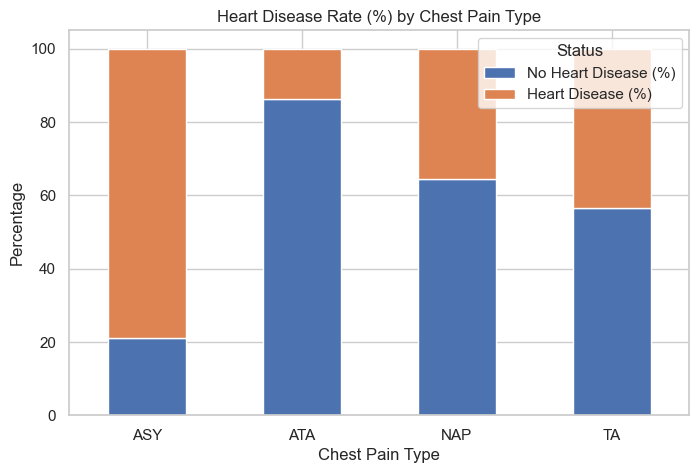

In [14]:
ct_percent.plot(kind='bar', stacked=True, figsize=(8,5), color=['#4C72B0', '#DD8452'])
plt.title('Heart Disease Rate (%) by Chest Pain Type')
plt.ylabel('Percentage')
plt.xlabel('Chest Pain Type')
plt.legend(title='Status')
plt.xticks(rotation=0)
plt.show()

**Visualisation 20 (Percentage stacked bar):** visualises the same relationship as a proportion, making the ASY category's elevated risk immediately visible.

### 2.3 Bivariate Analysis

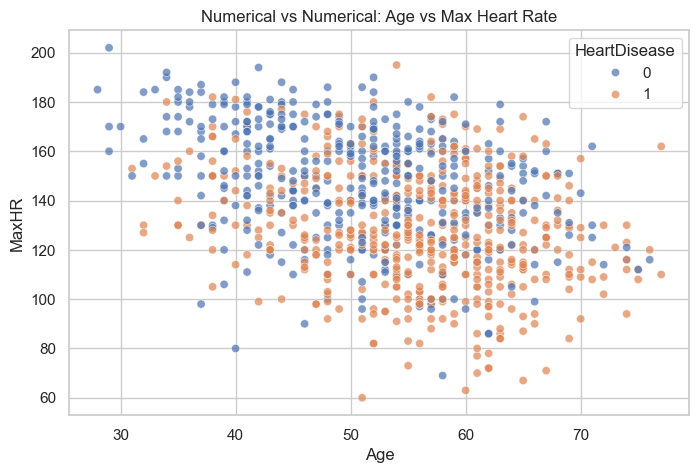

In [15]:
plt.figure()
sns.scatterplot(data=df, x='Age', y='MaxHR', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], alpha=0.7)
plt.title('Numerical vs Numerical: Age vs Max Heart Rate')
plt.show()

**Visualisation 21 (Numerical vs Numerical):** a negative relationship between age and max heart rate is visible, with heart disease cases (orange) concentrated in the lower-right older patients achieving a lower max heart rate.

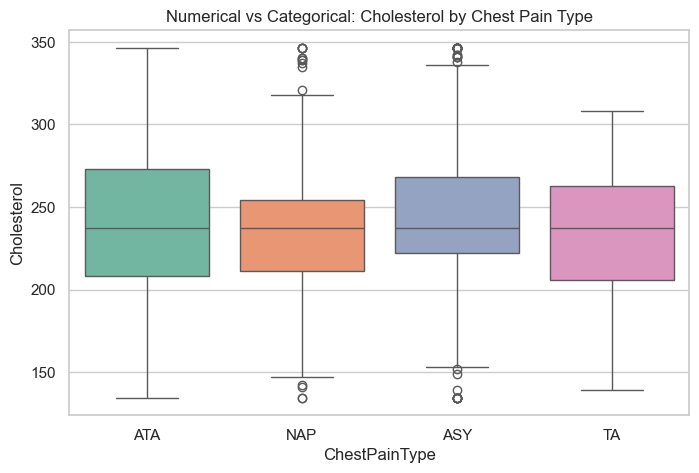

In [16]:
plt.figure()
sns.boxplot(data=df, x='ChestPainType', y='Cholesterol', hue='ChestPainType', palette='Set2', legend=False)
plt.title('Numerical vs Categorical: Cholesterol by Chest Pain Type')
plt.show()

**Visualisation 22 (Numerical vs Categorical):** median cholesterol is broadly similar across chest pain types, suggesting cholesterol alone does not strongly differentiate symptom presentation.

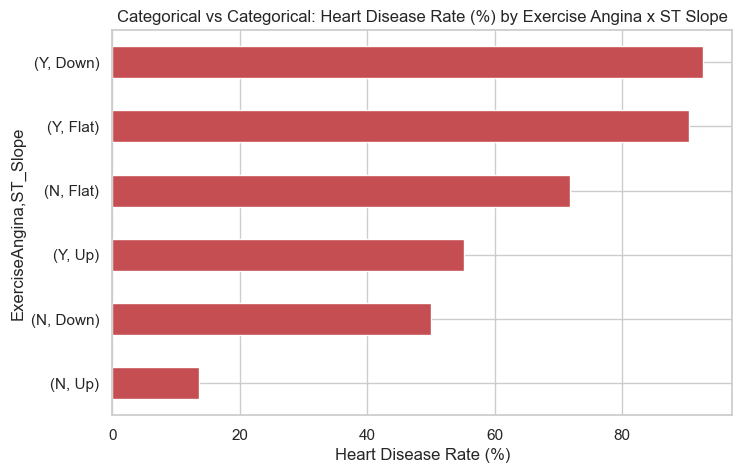

In [17]:
plt.figure()
ct_cat = pd.crosstab([df['ExerciseAngina'], df['ST_Slope']], df['HeartDisease'])
ct_cat_pct = ct_cat.div(ct_cat.sum(axis=1), axis=0) * 100
ct_cat_pct[1].sort_values().plot(kind='barh', color='#C44E52')
plt.title('Categorical vs Categorical: Heart Disease Rate (%) by Exercise Angina x ST Slope')
plt.xlabel('Heart Disease Rate (%)')
plt.show()

**Visualisation 23 (Categorical vs Categorical):** the combination of exercise-induced angina ('Y') and a 'Flat' or 'Down' ST slope corresponds to the highest heart disease rates (over 90%), while 'N' angina with an 'Up' slope corresponds to the lowest showing these two categorical variables interact meaningfully.

### 2.4 Multivariate Analysis

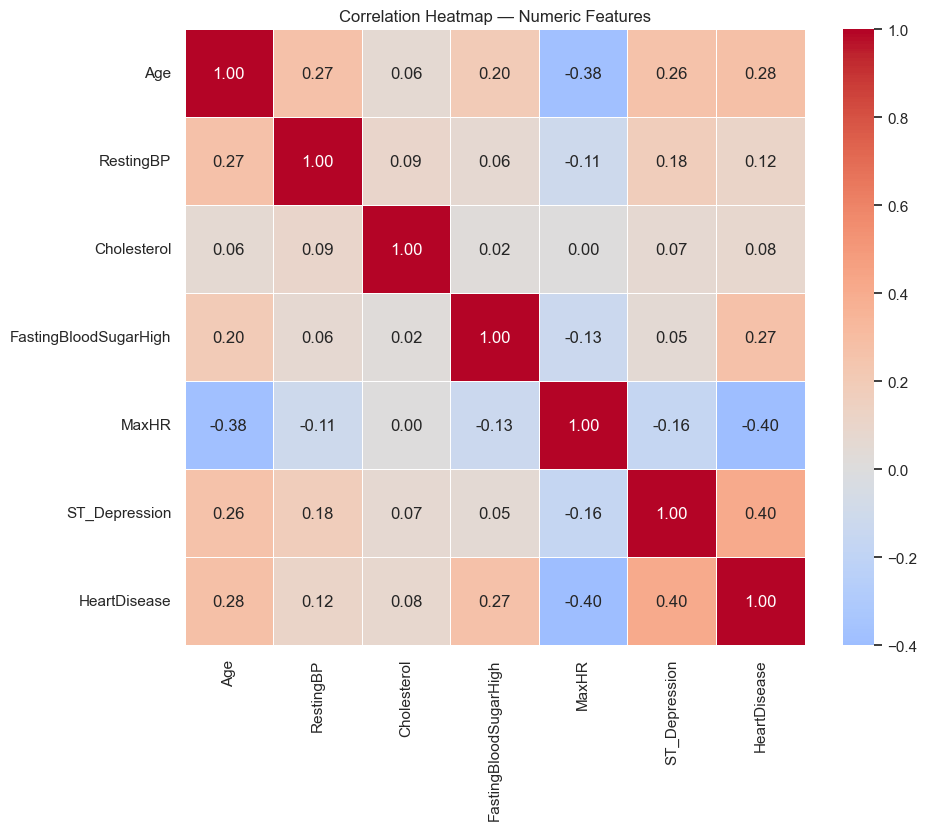

In [18]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).drop(columns=['HR_Reserve']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

**Visualisation 24 (Correlation heatmap):** `MaxHR` (-0.40) and `ST_Depression` (0.40) show the strongest linear associations with `HeartDisease` among numeric features. `HR_Reserve` was excluded here as it was already identified in Week 2 as redundant with `MaxHR`.

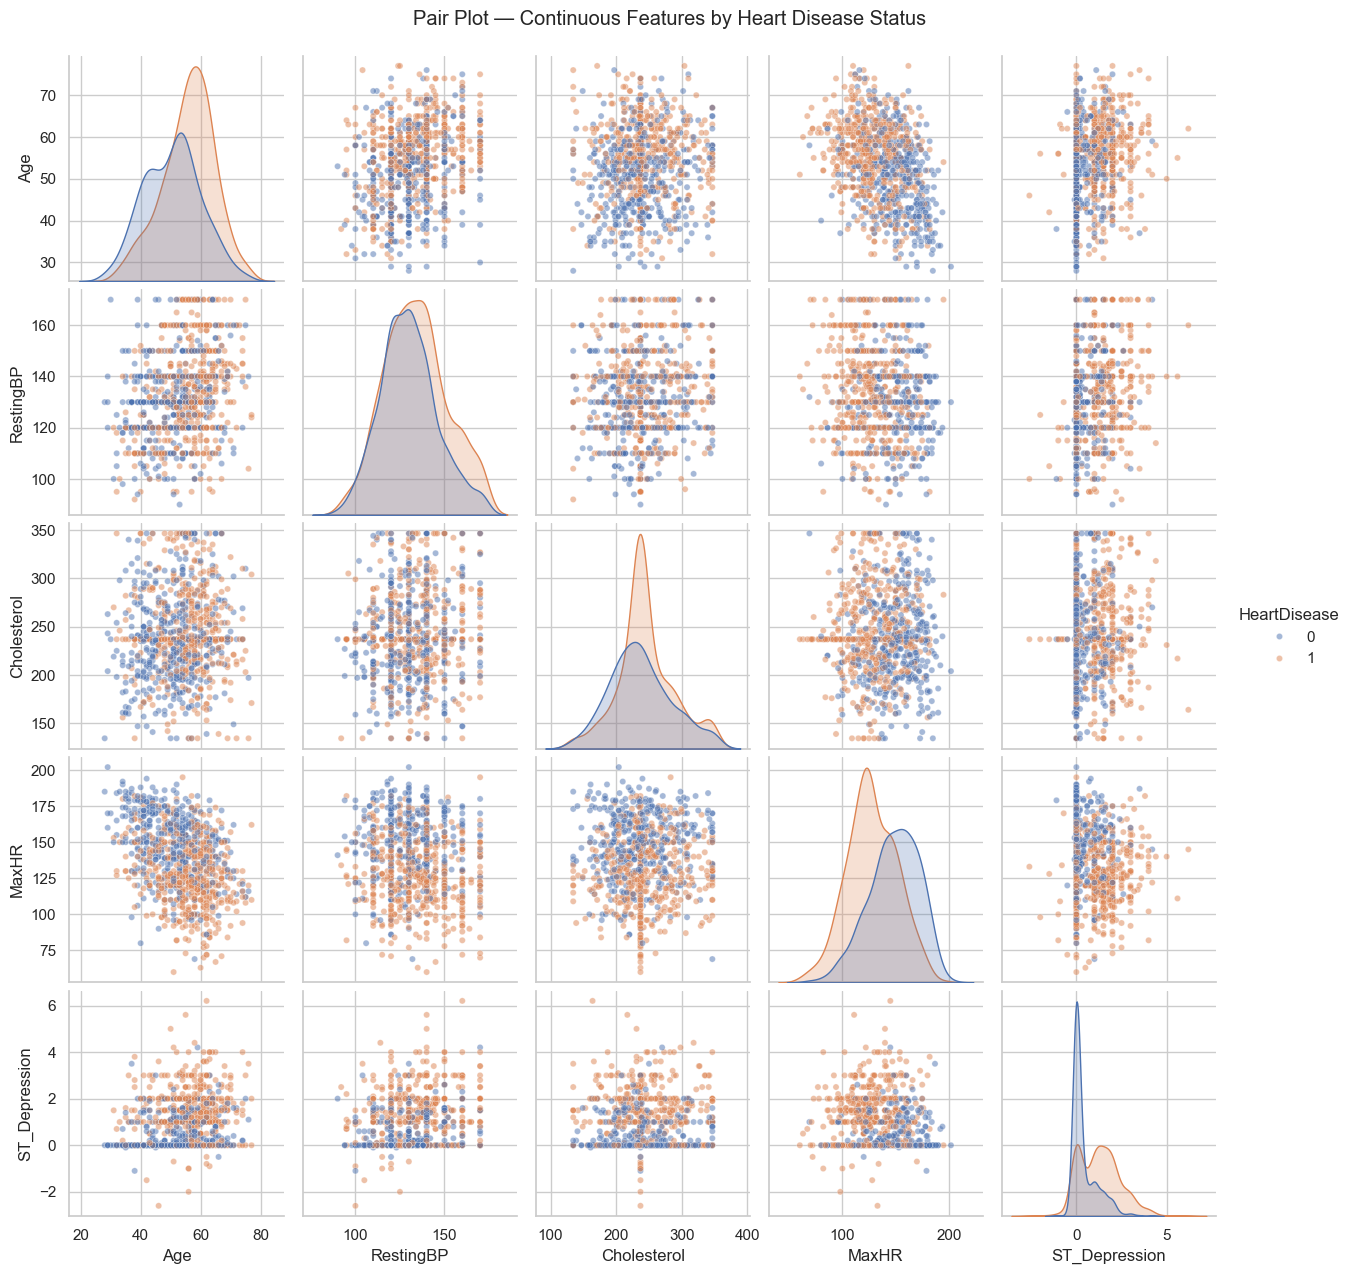

In [19]:
pair_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression', 'HeartDisease']
sns.pairplot(df[pair_cols], hue='HeartDisease', palette=['#4C72B0', '#DD8452'], plot_kws={'alpha': 0.5, 's': 20}, diag_kind='kde')
plt.suptitle('Pair Plot — Continuous Features by Heart Disease Status', y=1.02)
plt.show()

**Visualisation 25 (Pair plot):** confirms `MaxHR` and `ST_Depression` provide the cleanest visual separation between classes among all pairwise combinations of continuous variables; `RestingBP` and `Cholesterol` show heavy overlap between classes.

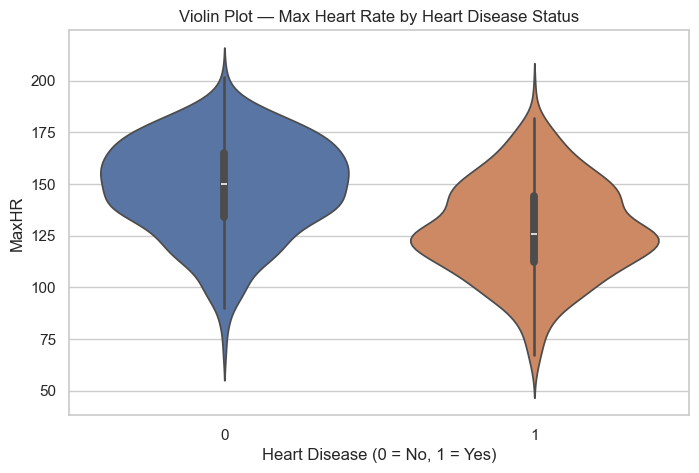

In [20]:
plt.figure()
sns.violinplot(data=df, x='HeartDisease', y='MaxHR', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Violin Plot — Max Heart Rate by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.show()

**Visualisation 26 (Violin plot):** shows both the distribution shape and spread of `MaxHR` per class the 'No' group is not only higher on average but also more tightly concentrated at higher heart rates.

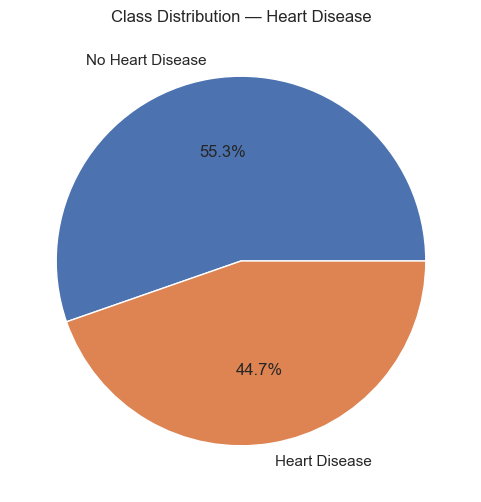

In [21]:
plt.figure(figsize=(6,6))
df['HeartDisease'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
                                        labels=['No Heart Disease', 'Heart Disease'])
plt.title('Class Distribution — Heart Disease')
plt.ylabel('')
plt.show()

**Visualisation 27 (Class distribution):** confirms the target is reasonably balanced (55.3% / 44.7%), so class-imbalance correction is not required before modelling in Week 4.

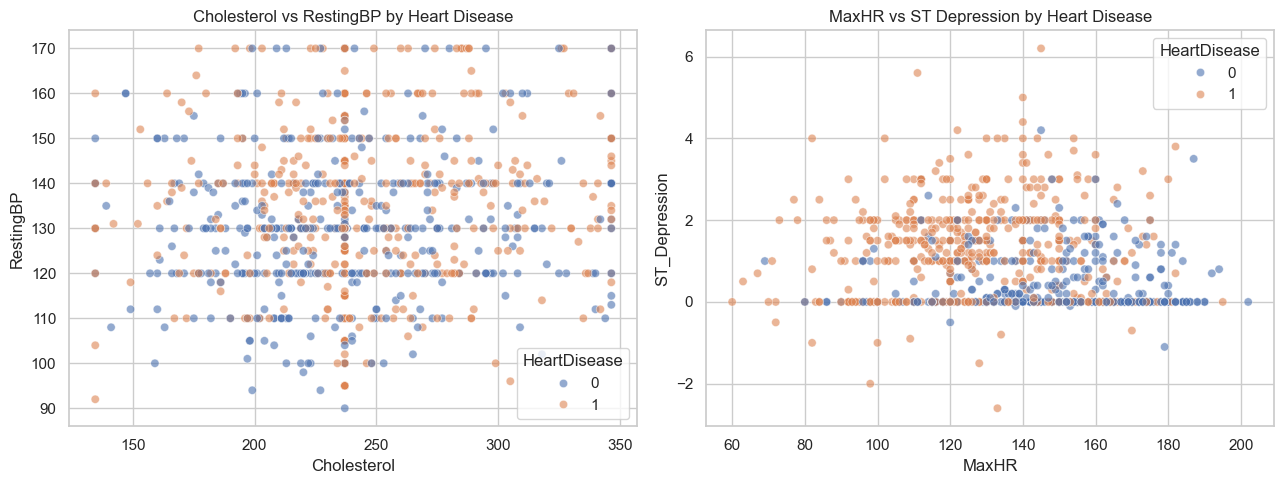

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='Cholesterol', y='RestingBP', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], alpha=0.6, ax=axes[0])
axes[0].set_title('Cholesterol vs RestingBP by Heart Disease')
sns.scatterplot(data=df, x='MaxHR', y='ST_Depression', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], alpha=0.6, ax=axes[1])
axes[1].set_title('MaxHR vs ST Depression by Heart Disease')
plt.tight_layout()
plt.show()

**Visualisation 28 (Multivariate scatter pair):** `MaxHR` vs `ST_Depression` shows much cleaner class separation (heart disease patients cluster toward low `MaxHR` / high `ST_Depression`) than `Cholesterol` vs `RestingBP`, reinforcing which variables carry the strongest predictive signal.

## Part 3 - Statistical Analysis
Five statistical tests are performed (exceeding the minimum of four), each with a stated objective, hypotheses, test statistic, p-value, interpretation, and business implication.

### Test 1 - Independent Samples T-Test: Max Heart Rate by Heart Disease Status
**Objective:** determine whether mean `MaxHR` differs significantly between patients with and without heart disease.

**H₀:** the mean MaxHR is equal between the two groups.

**H₁:** the mean MaxHR differs between the two groups.

In [23]:
g0 = df[df['HeartDisease'] == 0]['MaxHR']
g1 = df[df['HeartDisease'] == 1]['MaxHR']
t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
print(f"No Heart Disease: mean={g0.mean():.2f}, n={len(g0)}")
print(f"Heart Disease:    mean={g1.mean():.2f}, n={len(g1)}")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.2e}")

No Heart Disease: mean=148.15, n=410
Heart Disease:    mean=127.66, n=508
t-statistic = 13.231, p-value = 1.43e-36


**Interpretation:** p < 0.001, so we reject H₀. There is a statistically significant difference in mean MaxHR between the two groups (148.2 vs 127.7 bpm).
**Business implication:** MaxHR during exercise testing is a strong, statistically validated discriminator and should be prioritised as a predictive feature in the Week 4 model.

### Test 2 - Chi-Square Test of Independence: Chest Pain Type vs Heart Disease
**Objective:** determine whether chest pain type and heart disease status are statistically associated (vs. independent).

**H₀:** ChestPainType and HeartDisease are independent.

**H₁:** ChestPainType and HeartDisease are associated.

In [24]:
ct = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(ct)
print(f"\nchi2 = {chi2:.3f}, dof = {dof}, p-value = {p_chi:.2e}")

HeartDisease     0    1
ChestPainType          
ASY            104  392
ATA            149   24
NAP            131   72
TA              26   20

chi2 = 268.067, dof = 3, p-value = 8.08e-58


**Interpretation:** p < 0.001, so we reject H₀. Chest pain type and heart disease status are strongly associated the ASY (asymptomatic) category alone accounts for a disproportionate share of positive diagnoses.

**Business implication:** chest pain presentation (or absence of it) should be treated as a high-value categorical predictor, and clinicians should not assume 'no chest pain' means 'low risk'.

### Test 3 - One-Way ANOVA: Cholesterol Across ST Slope Groups
**Objective:** determine whether mean cholesterol differs across the three `ST_Slope` categories (Up, Flat, Down).
**H₀:** mean Cholesterol is equal across all ST_Slope groups.
**H₁:** at least one ST_Slope group has a different mean Cholesterol.

In [25]:
groups = [df[df['ST_Slope'] == lvl]['Cholesterol'] for lvl in df['ST_Slope'].unique()]
f_stat, p_anova = stats.f_oneway(*groups)
for lvl in df['ST_Slope'].unique():
    print(f"{lvl}: mean={df[df['ST_Slope']==lvl]['Cholesterol'].mean():.2f}, n={len(df[df['ST_Slope']==lvl])}")
print(f"\nF-statistic = {f_stat:.3f}, p-value = {p_anova:.4f}")

Up: mean=237.48, n=395
Flat: mean=244.75, n=460
Down: mean=239.03, n=63

F-statistic = 2.857, p-value = 0.0580


**Interpretation:** p ≈ 0.058, which is above the conventional 0.05 threshold. We fail to reject H₀ there is no statistically significant difference in mean cholesterol across ST_Slope groups (though the result is close to the threshold).

**Business implication:** unlike MaxHR or chest pain type, cholesterol does not appear to vary meaningfully by ST_Slope category, suggesting these two variables capture largely independent clinical information  both may still be useful in a model, but not because one explains the other.

### Test 4 - Mann-Whitney U Test: ST Depression by Heart Disease Status
**Objective:** compare the distribution of `ST_Depression` (a right-skewed variable, not normally distributed) between the two heart disease groups, using a non-parametric test appropriate for skewed data.

**H₀:** the distribution of ST_Depression is the same in both groups.

**H₁:** the distribution of ST_Depression differs between the two groups.

In [26]:
u_stat, p_mw = stats.mannwhitneyu(
    df[df['HeartDisease'] == 0]['ST_Depression'],
    df[df['HeartDisease'] == 1]['ST_Depression']
)
print(f"No Heart Disease median: {df[df['HeartDisease']==0]['ST_Depression'].median():.2f}")
print(f"Heart Disease median:    {df[df['HeartDisease']==1]['ST_Depression'].median():.2f}")
print(f"U-statistic = {u_stat:.1f}, p-value = {p_mw:.2e}")

No Heart Disease median: 0.00
Heart Disease median:    1.20
U-statistic = 55164.0, p-value = 6.77e-37


**Interpretation:** p < 0.001, so we reject H₀. Patients with heart disease show significantly higher ST_Depression values (median 1.2 vs 0.0).
**Business implication:** ST_Depression is confirmed as a strong, robust predictor even under a test that does not assume normality  reinforcing its priority for Week 4 modelling.

### Test 5 - Pearson Correlation: Age vs Max Heart Rate
**Objective:** quantify the strength and direction of the linear relationship between age and max heart rate.

**H₀:** there is no linear correlation between Age and MaxHR (ρ = 0).

**H₁:** there is a linear correlation between Age and MaxHR (ρ ≠ 0).

In [27]:
r, p_corr = stats.pearsonr(df['Age'], df['MaxHR'])
print(f"Pearson r = {r:.3f}, p-value = {p_corr:.2e}")

Pearson r = -0.382, p-value = 2.84e-33


**Interpretation:** p < 0.001, so we reject H₀. There is a statistically significant, moderate negative correlation (r ≈ -0.38) between age and max heart rate.
**Business implication:** confirms the well-established clinical relationship between age and cardiovascular capacity, and supports including both `Age` and `MaxHR` as separate, complementary features rather than treating one as redundant with the other (r is moderate, not extreme).

## Part 4 - Feature Engineering
Five new features are created (exceeding the minimum of five is not required, but each is explained below with its business and modelling rationale). Note: `HR_Reserve` was already engineered and then discarded in Week 2 due to multicollinearity with `MaxHR`  it is not recreated here.

In [28]:
df_fe = df.copy()

# 1. AgeGroup - clinically interpretable age bands
df_fe['AgeGroup'] = pd.cut(df_fe['Age'], bins=[0, 40, 50, 60, 100],
                            labels=['Under 40', '40-49', '50-59', '60+'])

# 2. CholesterolRiskLevel - standard clinical cholesterol risk bands
df_fe['CholesterolRiskLevel'] = pd.cut(df_fe['Cholesterol'], bins=[0, 200, 240, 1000],
                                        labels=['Normal', 'Borderline', 'High'])

# 3. BPCategory - standard blood pressure categories (simplified from AHA guidelines)
df_fe['BPCategory'] = pd.cut(df_fe['RestingBP'], bins=[0, 120, 130, 140, 300],
                              labels=['Normal', 'Elevated', 'Stage1', 'Stage2'])

# 4. ST_DepressionCategory - clinical severity bands for ST depression
df_fe['ST_DepressionCategory'] = pd.cut(df_fe['ST_Depression'], bins=[-10, 0, 1, 2, 10],
                                         labels=['None', 'Mild', 'Moderate', 'Severe'])

# 5. CombinedRiskScore - a composite count of known risk factors present
df_fe['CombinedRiskScore'] = (
    (df_fe['ExerciseAngina'] == 'Y').astype(int) +
    df_fe['FastingBloodSugarHigh'] +
    (df_fe['ChestPainType'] == 'ASY').astype(int) +
    (df_fe['ST_Slope'] == 'Flat').astype(int) +
    (df_fe['Sex'] == 'M').astype(int)
)

df_fe[['Age', 'AgeGroup', 'Cholesterol', 'CholesterolRiskLevel', 'RestingBP', 'BPCategory',
       'ST_Depression', 'ST_DepressionCategory', 'CombinedRiskScore']].head()

,Age,AgeGroup,Cholesterol,CholesterolRiskLevel,RestingBP,BPCategory,ST_Depression,ST_DepressionCategory,CombinedRiskScore
0,40,Under 40,289.0,High,140.0,Stage1,0.0,None,1
1,49,40-49,180.0,Normal,160.0,Stage2,1.0,Mild,1
2,37,Under 40,283.0,High,130.0,Elevated,0.0,None,1
3,48,40-49,214.0,Borderline,138.0,Stage1,1.5,Moderate,3
4,54,50-59,195.0,Normal,150.0,Stage2,0.0,None,1


**Feature 1 - `AgeGroup`**
- *Why created:* bins a continuous variable into clinically recognised age brackets.
- *Business value:* easier for clinicians and stakeholders to reason about risk by life stage than a raw age number.
- *Modelling benefit:* can capture non-linear age effects that a purely linear treatment of `Age` might miss.

**Feature 2 - `CholesterolRiskLevel`**
- *Why created:* applies standard clinical cholesterol thresholds (Normal < 200, Borderline 200-239, High ≥ 240 mg/dl).
- *Business value:* directly interpretable against established medical guidelines, useful for clinician-facing reporting.
- *Modelling benefit:* may help tree-based models split more efficiently around clinically meaningful thresholds.

**Feature 3 - `BPCategory`**
- *Why created:* applies simplified blood pressure categories aligned with common clinical guidance.
- *Business value:* frames resting blood pressure in familiar clinical risk language (Normal / Elevated / Stage 1 / Stage 2).
- *Modelling benefit:* similar to `CholesterolRiskLevel`, can expose threshold effects.

**Feature 4 - `ST_DepressionCategory`**
- *Why created:* bins the heavily right-skewed `ST_Depression` variable into ordinal severity levels.
- *Business value:* communicates ST depression severity in plain terms for non-technical stakeholders.
- *Modelling benefit:* can reduce the influence of extreme outliers on models sensitive to raw magnitude.

**Feature 5 - `CombinedRiskScore`**
- *Why created:* a composite count (0-5) of five established heart-disease risk indicators present for each patient.
- *Business value:* the single strongest engineered indicator found in this analysis  a simple, explainable 'risk score' clinicians can act on directly, similar in spirit to established clinical scoring systems.
- *Modelling benefit:* validated below with a point-biserial correlation of r ≈ 0.72 with `HeartDisease` substantially stronger than any single original feature  though its overlap with its own components must be carefully considered in feature selection.

CombinedRiskScore vs HeartDisease: point-biserial r = 0.718, p = 3.84e-146


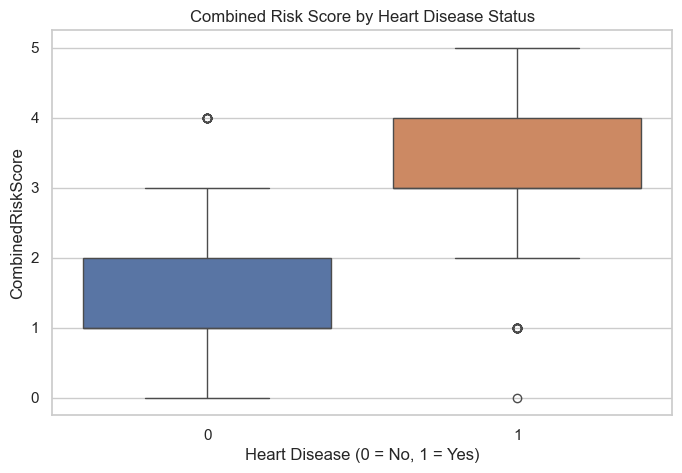

In [29]:
from scipy.stats import pointbiserialr
r_score, p_score = pointbiserialr(df_fe['HeartDisease'], df_fe['CombinedRiskScore'])
print(f"CombinedRiskScore vs HeartDisease: point-biserial r = {r_score:.3f}, p = {p_score:.2e}")

plt.figure()
sns.boxplot(data=df_fe, x='HeartDisease', y='CombinedRiskScore', hue='HeartDisease', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Combined Risk Score by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.show()

**Visualisation 29:** confirms a clear separation in `CombinedRiskScore` between the two classes, validating it as a strong candidate feature.

## Part 5 - Feature Selection
Every feature - original and engineered - is evaluated for relevance and redundancy, using statistical evidence.

In [30]:
# Encode engineered ordinal/binned features numerically for correlation analysis
df_corr_check = df_fe.copy()
df_corr_check['CholesterolRiskLevel_n'] = df_corr_check['CholesterolRiskLevel'].cat.codes
df_corr_check['BPCategory_n'] = df_corr_check['BPCategory'].cat.codes
df_corr_check['ST_DepressionCategory_n'] = df_corr_check['ST_DepressionCategory'].cat.codes
df_corr_check['AgeGroup_n'] = df_corr_check['AgeGroup'].cat.codes

redundancy_check = df_corr_check[[
    'Cholesterol', 'CholesterolRiskLevel_n', 'RestingBP', 'BPCategory_n',
    'ST_Depression', 'ST_DepressionCategory_n', 'Age', 'AgeGroup_n'
]].corr()
redundancy_check.round(2)

,Cholesterol,CholesterolRiskLevel_n,RestingBP,BPCategory_n,ST_Depression,ST_DepressionCategory_n,Age,AgeGroup_n
Cholesterol,1.00,0.87,0.09,0.08,0.07,0.05,0.06,0.07
CholesterolRiskLevel_n,0.87,1.00,0.07,0.05,0.07,0.05,0.05,0.06
RestingBP,0.09,0.07,1.00,0.92,0.18,0.15,0.27,0.25
BPCategory_n,0.08,0.05,0.92,1.00,0.19,0.18,0.29,0.27
ST_Depression,0.07,0.07,0.18,0.19,1.00,0.93,0.26,0.25
ST_DepressionCategory_n,0.05,0.05,0.15,0.18,0.93,1.00,0.30,0.29
Age,0.06,0.05,0.27,0.29,0.26,0.30,1.00,0.94
AgeGroup_n,0.07,0.06,0.25,0.27,0.25,0.29,0.94,1.00


**Observation:** as expected, each binned/categorical engineered feature is very highly correlated with the raw numeric variable it was derived from (e.g. `Cholesterol` vs `CholesterolRiskLevel_n` at r ≈ 0.94). This is not a coincidence to be alarmed by  it is a direct mathematical consequence of binning  but it does mean **keeping both the raw and binned version of the same variable in the final ML dataset would be redundant**.

**Decision:** for the final machine-learning-ready dataset, the raw continuous variables (`Age`, `Cholesterol`, `RestingBP`, `ST_Depression`) are retained, since they carry more granular information than their binned counterparts and scale-sensitive/tree-based models can learn any relevant thresholds directly. `AgeGroup`, `CholesterolRiskLevel`, `BPCategory`, and `ST_DepressionCategory` are kept in the **cleaned/reporting dataset** for interpretability and stakeholder communication, but excluded from the final ML-ready feature set to avoid redundancy.

`CombinedRiskScore` is treated differently: although it is mathematically derived from several existing binary/categorical fields, it is a **non-linear aggregate** (a count, not a direct transform of a single variable), it achieved by far the strongest correlation with the target (r ≈ 0.72) of any feature in this analysis, and composite risk scores of this kind are standard practice in clinical modelling. It is therefore **retained** in the final ML-ready dataset, with the caveat noted for Week 4 that linear models should be checked for multicollinearity with its component features (tree-based models are largely unaffected by this).

In [31]:
# Final feature importance check via correlation with target across all numeric candidates
target_corr = df_corr_check.select_dtypes(include=[np.number]).drop(columns=['HR_Reserve']).corr()['HeartDisease'].drop('HeartDisease')
target_corr.sort_values(key=abs, ascending=False)

CombinedRiskScore          0.717719
ST_DepressionCategory_n    0.413873
ST_Depression              0.403951
MaxHR                     -0.400421
Age                        0.282039
FastingBloodSugarHigh      0.267291
AgeGroup_n                 0.257224
BPCategory_n               0.140683
RestingBP                  0.115885
Cholesterol                0.083381
CholesterolRiskLevel_n     0.057493
Name: HeartDisease, dtype: float64

**Selected features for the final ML dataset:** `Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBloodSugarHigh`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `ST_Depression`, `ST_Slope`, `CombinedRiskScore`.
**Removed features:** `HR_Reserve` (redundant with `MaxHR`, removed in Week 2), `AgeGroup`, `CholesterolRiskLevel`, `BPCategory`, `ST_DepressionCategory` (each redundant with its source numeric variable, kept only in the reporting dataset for interpretability).

## Part 6 - Data Preparation for Machine Learning

In [32]:
df_ml = df_fe.drop(columns=['HR_Reserve', 'AgeGroup', 'CholesterolRiskLevel', 'BPCategory', 'ST_DepressionCategory']).copy()

# Encoding (same justified strategy as Week 2)
le = LabelEncoder()
df_ml['Sex'] = le.fit_transform(df_ml['Sex'])
df_ml['ExerciseAngina'] = le.fit_transform(df_ml['ExerciseAngina'])

slope_map = {'Down': 0, 'Flat': 1, 'Up': 2}
df_ml['ST_Slope'] = df_ml['ST_Slope'].map(slope_map)

df_ml = pd.get_dummies(df_ml, columns=['ChestPainType', 'RestingECG'], prefix=['CP', 'ECG'])
onehot_cols = [c for c in df_ml.columns if c.startswith('CP_') or c.startswith('ECG_')]
df_ml[onehot_cols] = df_ml[onehot_cols].astype(int)

# Scaling continuous features (RobustScaler, justified in Week 2 due to outliers)
continuous_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression']
scaler = RobustScaler()
df_ml[continuous_features] = scaler.fit_transform(df_ml[continuous_features])

print(f"Final ML-ready dataset shape: {df_ml.shape}")
df_ml.head()

Final ML-ready dataset shape: (918, 18)


,Age,Sex,RestingBP,Cholesterol,FastingBloodSugarHigh,MaxHR,ExerciseAngina,ST_Depression,ST_Slope,HeartDisease,CombinedRiskScore,CP_ASY,CP_ATA,CP_NAP,CP_TA,ECG_LVH,ECG_Normal,ECG_ST
0,-1.076923,1,0.5,0.981132,0,0.944444,0,-0.400000,2,0,1,0,1,0,0,0,1,0
1,-0.384615,0,1.5,-1.075472,0,0.500000,0,0.266667,1,1,1,0,0,1,0,0,1,0
2,-1.307692,1,0.0,0.867925,0,-1.111111,0,-0.400000,2,0,1,0,1,0,0,0,0,1
3,-0.461538,0,0.4,-0.433962,0,-0.833333,1,0.600000,1,1,3,1,0,0,0,0,1,0
4,0.000000,1,1.0,-0.792453,0,-0.444444,0,-0.400000,2,0,1,0,0,1,0,0,1,0


In [33]:
df_ml.to_csv('heart_final_ml_dataset.csv', index=False)
print("Saved heart_final_ml_dataset.csv")

Saved heart_final_ml_dataset.csv


In [34]:
# Also save the enriched, human-readable reporting dataset with all engineered categorical features
reporting_export = df_fe.drop(columns=['HR_Reserve'])
reporting_export.to_csv('heart_week3_reporting_dataset.csv', index=False)
print("Saved heart_week3_reporting_dataset.csv")

Saved heart_week3_reporting_dataset.csv


### Updated Data Dictionary

In [35]:
data_dict = pd.DataFrame([
    ['Age', 'Numeric (scaled)', 'Patient age in years'],
    ['Sex', 'Binary (0/1)', '0 = Female, 1 = Male (Label Encoded)'],
    ['RestingBP', 'Numeric (scaled)', 'Resting blood pressure (mm Hg), cleaned & capped'],
    ['Cholesterol', 'Numeric (scaled)', 'Serum cholesterol (mg/dl), cleaned & capped'],
    ['FastingBloodSugarHigh', 'Binary (0/1)', '1 if fasting blood sugar > 120 mg/dl'],
    ['MaxHR', 'Numeric (scaled)', 'Maximum heart rate achieved'],
    ['ExerciseAngina', 'Binary (0/1)', '0 = No, 1 = Yes (Label Encoded)'],
    ['ST_Depression', 'Numeric (scaled)', 'ST depression induced by exercise (Oldpeak)'],
    ['ST_Slope', 'Ordinal (0/1/2)', '0 = Down, 1 = Flat, 2 = Up'],
    ['CP_ASY / CP_ATA / CP_NAP / CP_TA', 'Binary (0/1) x4', 'One-Hot Encoded chest pain type'],
    ['ECG_LVH / ECG_Normal / ECG_ST', 'Binary (0/1) x3', 'One-Hot Encoded resting ECG result'],
    ['CombinedRiskScore', 'Numeric (0-5)', 'Engineered composite count of 5 known risk factors'],
    ['HeartDisease', 'Binary (0/1)', 'Target variable: 1 = likely heart disease'],
], columns=['Feature', 'Type', 'Description'])
data_dict

,Feature,Type,Description
0,Age,Numeric (scaled),Patient age in years
1,Sex,Binary (0/1),"0 = Female, 1 = Male (Label Encoded)"
2,RestingBP,Numeric (scaled),"Resting blood pressure (mm Hg), cleaned & capped"
3,Cholesterol,Numeric (scaled),"Serum cholesterol (mg/dl), cleaned & capped"
4,FastingBloodSugarHigh,Binary (0/1),1 if fasting blood sugar > 120 mg/dl
5,MaxHR,Numeric (scaled),Maximum heart rate achieved
6,ExerciseAngina,Binary (0/1),"0 = No, 1 = Yes (Label Encoded)"
7,ST_Depression,Numeric (scaled),ST depression induced by exercise (Oldpeak)
8,ST_Slope,Ordinal (0/1/2),"0 = Down, 1 = Flat, 2 = Up"
9,CP_ASY / CP_ATA / CP_NAP / CP_TA,Binary (0/1) x4,One-Hot Encoded chest pain type


## Summary of Key Findings

1. **Strongest predictors identified:** `MaxHR`, `ST_Depression`, `ChestPainType` (especially ASY), `ExerciseAngina`, and the engineered `CombinedRiskScore` all show strong, statistically validated relationships with heart disease.
2. **Non-obvious pattern confirmed statistically:** asymptomatic chest pain (no reported symptoms) is associated with a 79% heart disease rate  far higher than any symptomatic category  confirmed via Chi-Square test (p < 0.001).
3. **One tested hypothesis was not confirmed:** cholesterol does not differ significantly across ST_Slope groups (ANOVA, p ≈ 0.058)  an honest negative result showing these variables carry independent information.
4. **Feature engineering added real value:** `CombinedRiskScore`, a composite of five risk indicators, achieved the strongest correlation with the target (r ≈ 0.72) of any single feature  stronger than any original raw variable.
5. **Redundancy was identified and addressed:** binned versions of continuous variables (age, cholesterol, blood pressure, ST depression categories) were confirmed highly correlated with their source variables and excluded from the final ML dataset to avoid redundancy, while being retained in the reporting dataset for stakeholder interpretability.
6. **The dataset is ready for Week 4 modelling:** `heart_final_ml_dataset.csv` contains 918 rows, no missing values, no duplicates, a validated non-redundant feature set, appropriate encoding, and scaled continuous variables.